<a href="https://colab.research.google.com/github/priscilasalgadob/power-servers-dashboard/blob/main/largest_islands.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World's largest islands

This dataset `largest-islands.csv` contains information about the 100 largest islands in the world. The unit for the `area` column is km2.

In [ ]:
# Largest Islands Project

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()


Saving largest-islands.csv to largest-islands.csv


In [10]:
df = pd.read_csv("largest-islands.csv")
df.head()

,region,island,area,countries,climate,rank
0,Africa,Madagascar,591896,Madagascar,tropics,4
1,Antarctic,Kerguelen,6200,"Antarctic Lands, France",temperate,91
2,Asia,Sumba,11153,Indonesia,tropics,65
3,Asia,Hainan,34300,China,tropics,37
4,Asia,Taiwan,36198,Taiwan,tropics,36


In [11]:
tropical = df[df['climate'] == 'tropics']

top10 = tropical.nlargest(10, 'area')


print(top10[['island', 'region', 'area', 'countries', 'rank']])

        island         region    area                    countries  rank
86  New Guinea        Oceania  821400  Papua New Guinea, Indonesia     2
23      Borneo           Asia  755000  Indonesia, Malaysia, Brunei     3
0   Madagascar         Africa  591896                   Madagascar     4
28     Sumatra           Asia  480793                    Indonesia     6
22    Sulawesi           Asia  188522                    Indonesia    11
21        Java           Asia  129438                    Indonesia    13
80        Cuba  North America  109884                         Cuba    16
26       Luzon           Asia  104688                  Philippines    17
14    Mindanao           Asia   94630                  Philippines    19
73  Hispaniola  North America   76192    Dominican Republic, Haiti    23


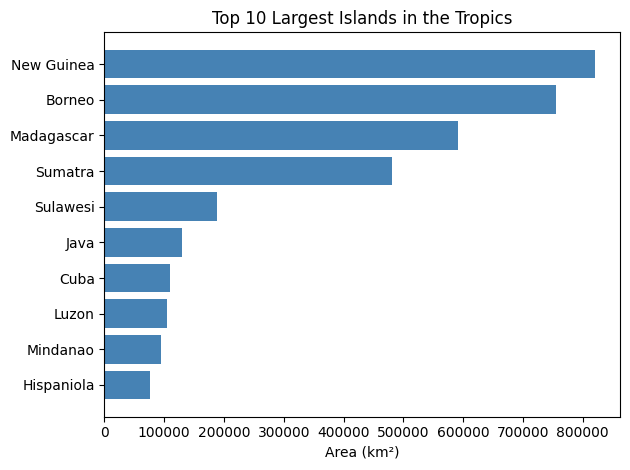

In [12]:
import matplotlib.pyplot as plt

top10_sorted = top10.sort_values('area', ascending=True)

plt.barh(top10_sorted['island'], top10_sorted['area'], color='steelblue')
plt.xlabel('Area (km²)')
plt.title('Top 10 Largest Islands in the Tropics')
plt.tight_layout()
plt.show()

In [13]:
region = df.groupby('region')
largest_per_region = region.apply(lambda x: x.nlargest(1, 'area'))

print(largest_per_region[['island', 'region', 'area', 'countries', 'rank']])

                                           island         region     area  \
region                                                                      
Africa        0                        Madagascar         Africa   591896   
Antarctic     1                         Kerguelen      Antarctic     6200   
Asia          23                           Borneo           Asia   755000   
Eurasia       35                         Sakhalin        Eurasia    76400   
Europe        41                        Greenland         Europe  2166086   
North America 75                    Baffin Island  North America   507451   
Oceania       86                       New Guinea        Oceania   821400   
South America 98  Isla Grande de Tierra del Fuego  South America    47992   

                                    countries  rank  
region                                               
Africa        0                    Madagascar     4  
Antarctic     1       Antarctic Lands, France    91  
Asia         

/tmp/ipykernel_1726/2830298863.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  largest_per_region = region.apply(lambda x: x.nlargest(1, 'area'))


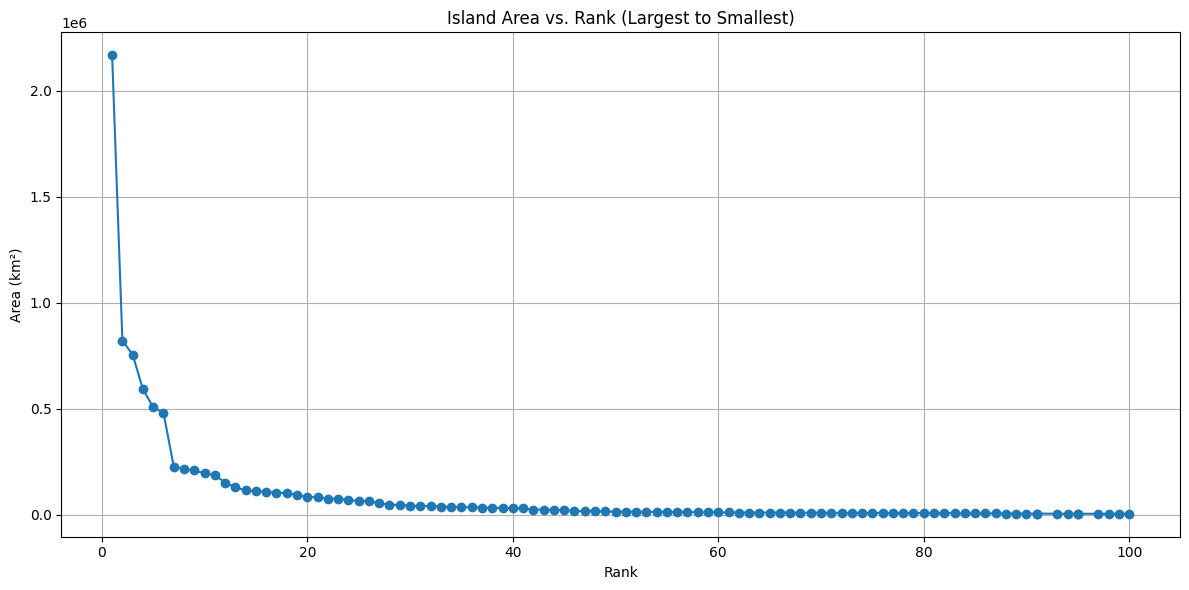

In [19]:
df_sorted_by_rank = df.sort_values(by='rank', ascending=True)

plt.figure(figsize=(12, 6))
plt.plot(df_sorted_by_rank['rank'], df_sorted_by_rank['area'], marker='o', linestyle='-')
plt.xlabel('Rank')
plt.ylabel('Area (km²)')
plt.title('Island Area vs. Rank (Largest to Smallest)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
multi_country_islands = df[df['countries'].str.contains(',')]
print(multi_country_islands[['island', 'countries', 'area', 'region', 'rank']])

                             island                    countries    area  \
1                         Kerguelen      Antarctic Lands, France    6200   
23                           Borneo  Indonesia, Malaysia, Brunei  755000   
45                          Ireland      Ireland, United Kingdom   84421   
50                           Cyprus       Cyprus, United Kingdom    9251   
73                       Hispaniola    Dominican Republic, Haiti   76192   
86                       New Guinea  Papua New Guinea, Indonesia  821400   
98  Isla Grande de Tierra del Fuego             Chile, Argentina   47992   

           region  rank  
1       Antarctic    91  
23           Asia     3  
45         Europe    20  
50         Europe    76  
73  North America    23  
86        Oceania     2  
98  South America    28  
